In [298]:
from typing import Callable, Optional, Sequence

import jax
import jax.numpy as jnp
from jax.typing import ArrayLike
from flax import nnx

from probjax.distributions.transformed_distribution import TransformedDistribution, Distribution
from probjax.distributions import Normal, Independent
from probjax.nn import CouplingMLP, Sequential, Flip



from probjax.core import inverse_and_logabsdet

In [374]:
jnp.exp(-3)

Array(0.05, dtype=float32, weak_type=True)

In [ ]:
from functools import partial
import numpy as np

def affine_bijector(params, x):
    shift, log_scale = jnp.split(params, 2)
    scale = jax.nn.sigmoid(log_scale)*10 + 1e-1
    return scale*x + shift


def build_affine_coupling_block(split_dim, params_dim, i):
    return [CouplingMLP(split_dim, params_dim, affine_bijector, rngs=nnx.Rngs(i)), Flip()]



class AffineCouplingFlow(TransformedDistribution,nnx.Module, experimental_pytree=True):
    def __init__(self, input_dim, num_transforms, rngs) -> None:
        split_dim = input_dim // 2
        params_dim = (input_dim - split_dim)*2
        coupling_net = partial(CouplingMLP, split_dim, params_dim, affine_bijector)

        transforms = []
        for i in range(num_transforms):
            transforms += [coupling_net(rngs=rngs)]
            if i < num_transforms - 1:
                transforms += [Flip()]
        self.transform = Sequential(*transforms)
        self.mu0 = nnx.Variable(jnp.zeros(input_dim))
        self.std0 = nnx.Variable(jnp.ones(input_dim))
        self.base_dist = nnx.Variable(Independent(Normal(self.mu0, self.std0), 1))

        super().__init__(self.base_dist, self.transform)


In [472]:
p = AffineCouplingFlow(4, 5, nnx.Rngs(1))

params = nnx.state(p, nnx.Param)

In [473]:
x1 = jax.random.normal(jax.random.PRNGKey(0), (1000, 4)) -2 
x2 = jax.random.normal(jax.random.PRNGKey(1), (1000, 4)) +2

xs = jnp.concatenate([x1, x2], axis=0)

In [474]:
def loss(params):
    nnx.update(p, params)
    return -jnp.mean(p.log_prob(xs))

In [475]:
import optax 

optimizer = optax.adam(1e-3)

@jax.jit
def update(params, opt_state):
    loss_val, grads = jax.value_and_grad(loss)(params)
    updates, opt_state = optimizer.update(grads, opt_state)
    new_params = optax.apply_updates(params, updates)
    return loss_val, new_params, opt_state

In [476]:
opt_state = optimizer.init(params)

In [477]:
for i in range(1000):
    loss_val, params, opt_state = update(params, opt_state)
    print(loss_val)

42.07733
41.894634
41.7033
41.50183
41.28794
41.056572
41.008457
40.706398
40.58811
40.455
40.308308
40.147026
39.97116
39.7772
39.561745
39.33708
39.067024
38.888664
52.98548
38.44201
38.345486
38.22923
38.092705
37.919132
37.718952
37.492825
37.225636
36.916603
36.5209
36.0506
35.506283
34.913406
38.375698
33.95901
33.740883
33.648808
33.74454
33.93547
34.15994
34.321827
34.34528
33.869175
34.12644
33.84102
33.429127
32.95567
32.495705
32.037582
31.594486
31.16393
30.754791
30.373861
30.004818
29.655594
29.311481
29.000286
28.718506
28.45731
28.198095
27.916517
27.667013
27.429632
27.190916
26.992403
26.68404
26.417044
26.168198
25.916346
25.64473
25.35942
25.15162
24.863894
24.615604
24.391169
24.161278
23.945494
23.685047
23.519537
23.287577
23.103733
22.926376
22.7444
22.590014
22.439703
22.299326
22.171131
21.90393
21.681467
21.401068
21.170345
21.039509
21.013582
20.998774
21.079895
21.347973
21.218384
21.24892
21.214916
21.1052
20.969536
20.625582
20.41335
20.202215
19.994802
1

In [468]:
nnx.update(p, params)

In [469]:
samples = p.sample(jax.random.PRNGKey(0), (1000, ))

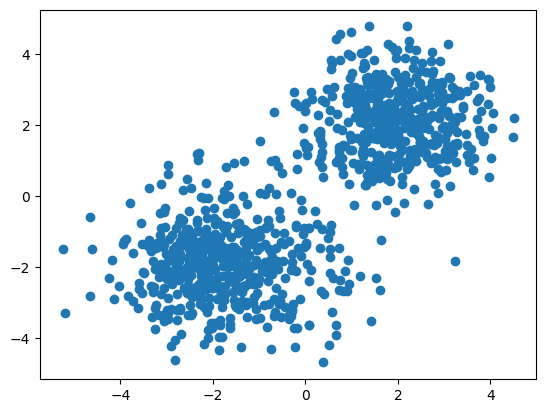

In [470]:
import matplotlib.pyplot as plt

plt.scatter(samples[:, 0], samples[:, 1])